# Chapter 18 Lab — The General Linear Model (Python)

In this lab you will build, from the ground up, the machinery at the heart of every first-level fMRI analysis: the General Linear Model (GLM). We follow a four-step arc:

1. **Build a design matrix** from event onsets by convolving stimulus functions with a canonical hemodynamic response function (HRF)
2. **Fit the GLM** to a simulated voxel time series with ordinary least squares (OLS)
3. **Examine residuals and model fit**, and compute standard errors, t-values, and P values
4. **Test a simple contrast** comparing the two conditions

Because we simulate the data with known ground truth, you can see exactly how well the estimation machinery recovers the "right answer" — something you never get to check with real data.

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter installation. It uses only `numpy`, `scipy`, `pandas`, `matplotlib`, and `nilearn`, and all data are simulated — nothing to download. It accompanies the [chapter page](https://torwager.github.io/elements-of-fmri-tutorials/book/part4/ch18-the-general-linear-model-and).

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
# Setup — installs nilearn when it's missing (safe to re-run anywhere)
try:
    import nilearn  # noqa: F401 — already present on many local setups
except ImportError:
    import sys
    if "pyodide" in sys.modules:
        # Running in your browser (JupyterLite): install a browser-compatible version
        import piplite
        await piplite.install("nilearn==0.13.1")
    else:
        # Colab or local Python
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nilearn"])
print("nilearn ready:", __import__("nilearn").__version__)


nilearn ready: 0.14.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# nilearn provides convenient design-matrix construction and plotting
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.4.6 | pandas 3.0.5


## Step 1 — From event onsets to a design matrix

Modeling task-evoked BOLD signal starts with two ingredients:

- a **neural stimulus function** $s(t)$: an indicator that is 1 when we assume neural activity occurs (during events) and 0 elsewhere
- a **hemodynamic response function** $h(t)$: the sluggish vascular response to a brief burst of neural activity

Assuming the brain behaves as a **linear time invariant (LTI) system**, the predicted BOLD signal is their convolution:

::::{div}
:class: eq-tip
$$
x(t) = (s \ast h)(t)
$$
:::{div}
:class: eq-tip-text
x(t) — predicted BOLD signal · s(t) — neural stimulus function (1 during assumed activity, 0 elsewhere) · h(t) — hemodynamic response function · ∗ — convolution
:::
::::
:::{div}
:class: eq-where
*where* $x(t)$ *is the predicted BOLD signal,* $s(t)$ *the neural stimulus function,* $h(t)$ *the hemodynamic response function, and* $\ast$ *the convolution operator.*
:::

A popular canonical HRF is the difference of two gamma functions — the first creates the peak around 5–6 s, the second the later undershoot:

::::{div}
:class: eq-tip
$$
h(t) = \frac{t^{\alpha_1 - 1}\beta_1^{\alpha_1} e^{-\beta_1 t}}{\Gamma(\alpha_1)} - c\,\frac{t^{\alpha_2 - 1}\beta_2^{\alpha_2} e^{-\beta_2 t}}{\Gamma(\alpha_2)}
$$
:::{div}
:class: eq-tip-text
h(t) — HRF value at time t after a neural event · α₁, β₁ — shape and rate of the peak gamma · α₂, β₂ — shape and rate of the undershoot gamma · c — undershoot amplitude · Γ — gamma function
:::
::::
:::{div}
:class: eq-where
*where* $t$ *is time since the neural event,* $\alpha_1, \beta_1$ *set the shape and rate of the first (peak) gamma function,* $\alpha_2, \beta_2$ *those of the second (undershoot) gamma,* $c$ *scales the undershoot, and* $\Gamma(\cdot)$ *is the gamma function.*
:::

with $\alpha_1 = 6$, $\alpha_2 = 16$, $\beta_1 = \beta_2 = 1$, $c = 1/6$. Conveniently, each term is exactly a gamma probability density, so we can build it with `scipy.stats.gamma.pdf`.

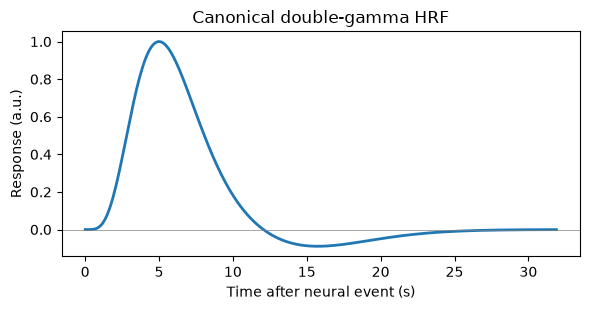

In [3]:
def canonical_hrf(t):
    # Double-gamma canonical HRF (SPM-style parameters), peak-normalized
    h = stats.gamma.pdf(t, 6, scale=1) - stats.gamma.pdf(t, 16, scale=1) / 6
    return h / h.max()

dt = 0.1                          # fine time resolution (s) for convolution
t_hrf = np.arange(0, 32, dt)      # HRF support: 32 s
hrf = canonical_hrf(t_hrf)

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(t_hrf, hrf, lw=2)
ax.axhline(0, color="gray", lw=0.5)
ax.set(xlabel="Time after neural event (s)", ylabel="Response (a.u.)",
       title="Canonical double-gamma HRF")
plt.tight_layout()

Note the two signatures of the canonical shape: a peak around 5–6 seconds, and a small undershoot that resolves by about 25–30 seconds. This is the "impulse response" of the assumed LTI system.

### Build the stimulus functions and convolve

We simulate a 6-minute run (180 volumes, TR = 2 s) with two event types, **A** and **B** (imagine famous vs. non-famous faces), each presented for 1 s at irregular intervals. We build each indicator vector on a fine time grid (0.1 s), convolve with the HRF, then **downsample to the scanner's sampling times** (one value per TR). The two convolved predictors, plus a column of ones for the intercept, form the design matrix $X$.

Design matrix shape (n x p): (180, 3)


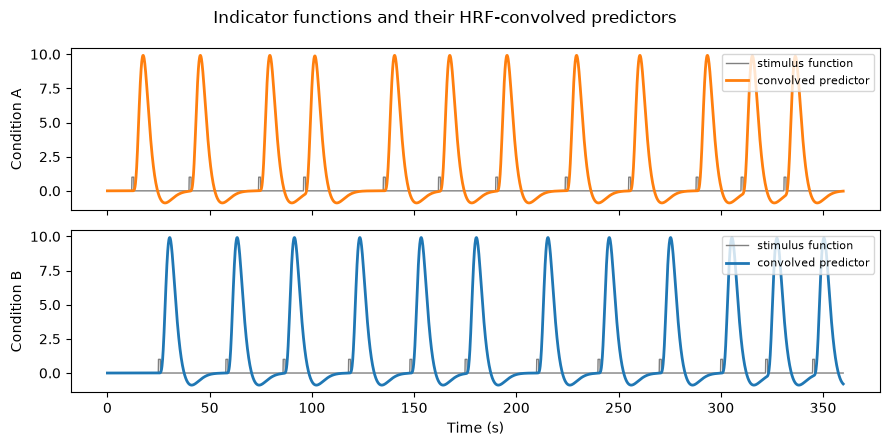

In [4]:
t_r = 2.0                          # repetition time (s)
n_scans = 180                      # number of volumes
run_len = n_scans * t_r            # 360 s
frame_times = np.arange(n_scans) * t_r

onsets_A = [12, 40, 74, 96, 135, 162, 190, 224, 255, 288, 310, 331]   # Condition A onsets (s): 12 events
onsets_B = [25, 58, 86, 118, 148, 175, 210, 240, 270, 300, 322, 345]   # Condition B onsets (s): 12 events
duration = 1.0                     # each event lasts 1 s

t_hi = np.arange(0, run_len, dt)   # fine time grid

def make_regressor(onsets):
    # Indicator function on the fine grid, convolved with the HRF
    stim = np.zeros_like(t_hi)
    for onset in onsets:
        stim[(t_hi >= onset) & (t_hi < onset + duration)] = 1.0
    x = np.convolve(stim, hrf)[: len(t_hi)]    # LTI prediction
    return stim, x

stim_A, x_A = make_regressor(onsets_A)
stim_B, x_B = make_regressor(onsets_B)

# Downsample to the volume acquisition times and assemble X
idx = np.round(frame_times / dt).astype(int)
X = np.column_stack([x_A[idx], x_B[idx], np.ones(n_scans)])
col_names = ["A", "B", "constant"]
print("Design matrix shape (n x p):", X.shape)

fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
for ax, stim, x, label, color in [(axes[0], stim_A, x_A, "A", "tab:orange"),
                                  (axes[1], stim_B, x_B, "B", "tab:blue")]:
    ax.plot(t_hi, stim, color="gray", lw=1, label="stimulus function")
    ax.plot(t_hi, x, color=color, lw=2, label="convolved predictor")
    ax.set(ylabel=f"Condition {label}")
    ax.legend(loc="upper right", fontsize=8)
axes[1].set(xlabel="Time (s)")
fig.suptitle("Indicator functions and their HRF-convolved predictors")
plt.tight_layout()

Each brief event produces a delayed, blurred response, and closely spaced events **superpose** — their responses add. That additivity is the LTI assumption doing its work.

### Cross-check with nilearn

In practice you rarely hand-roll the convolution. `nilearn.glm.first_level.make_first_level_design_matrix` takes an events table (onset, duration, trial_type) and does the same thing. Its `plot_design_matrix` companion draws the classic grayscale design-matrix image: one row per volume, one column per regressor.

correlation of hand-built vs. nilearn regressor A: r = 1.000
correlation of hand-built vs. nilearn regressor B: r = 1.000


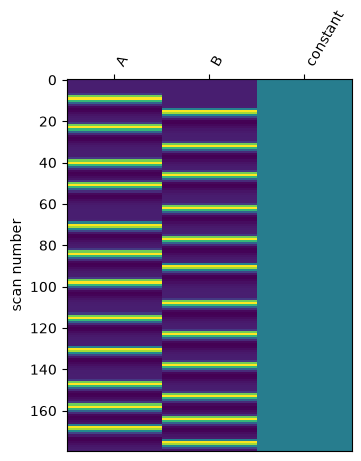

In [5]:
events = pd.DataFrame({
    "onset":      onsets_A + onsets_B,
    "duration":   duration,
    "trial_type": ["A"] * len(onsets_A) + ["B"] * len(onsets_B),
})

X_nilearn = make_first_level_design_matrix(
    frame_times, events, hrf_model="spm", drift_model=None)

ax = plot_design_matrix(X_nilearn)
ax.figure.set_size_inches(3.5, 4.5)

# Our hand-built regressors should be nearly identical to nilearn's
# ('spm' uses the same double-gamma parameters we coded by hand)
for ours, name in [(X[:, 0], "A"), (X[:, 1], "B")]:
    r = np.corrcoef(ours, X_nilearn[name])[0, 1]
    print(f"correlation of hand-built vs. nilearn regressor {name}: r = {r:.3f}")

The correlations are near 1: hand-built convolution and nilearn agree. From here on we use our hand-built `X` so every number is transparent.

## Step 2 — Fit the GLM with ordinary least squares

The structural model for one voxel's time series $y$ (an $n \times 1$ vector) is

::::{div}
:class: eq-tip
$$
y = X\beta + \epsilon, \qquad \epsilon \sim N(0, \sigma^2 I)
$$
:::{div}
:class: eq-tip-text
y — voxel time series (n × 1) · X — design matrix (n × p) · β — unknown amplitudes (p × 1) · ε — errors, independent with variance σ² · I — identity matrix
:::
::::
:::{div}
:class: eq-where
*where* $y$ *is the* $n \times 1$ *voxel time series,* $X$ *the* $n \times p$ *design matrix,* $\beta$ *the* $p \times 1$ *vector of unknown amplitudes,* $\epsilon$ *the vector of errors with variance* $\sigma^2$*, and* $I$ *the identity matrix.*
:::

Estimation finds the $\beta$ that minimizes the sum of squared errors $(y - X\beta)^T (y - X\beta)$. The GLM's superpower is that this has a closed-form solution — the **ordinary least squares (OLS)** estimate:

::::{div}
:class: eq-tip
$$
\hat{\beta} = (X^TX)^{-1}X^Ty
$$
:::{div}
:class: eq-tip-text
β̂ — estimated coefficients · X — design matrix (time × predictors) · y — voxel time series · ᵀ — transpose
:::
::::
:::{div}
:class: eq-where
*where* $\hat{\beta}$ *is the vector of estimated coefficients,* $X$ *the design matrix,* $y$ *the measured time series, and* $^T$ *the transpose operator.*
:::

We simulate a voxel where we *know* the truth: $\beta_A = 0.8$, $\beta_B = 0.4$, intercept $= 100$ (arbitrary signal units), with IID Gaussian noise ($\sigma = 2$). Then we recover the parameters with one line of linear algebra.

In [6]:
rng = np.random.default_rng(2024)              # seed for reproducible noise

beta_true = np.array([0.8, 0.4, 100.0])        # [A, B, intercept]
sigma_noise = 2.0                              # noise standard deviation (signal units)

y = X @ beta_true + sigma_noise * rng.standard_normal(n_scans)

# OLS: beta_hat = (X'X)^{-1} X'y  (solve() is more stable than inverting)
beta_hat = np.linalg.solve(X.T @ X, X.T @ y)

pd.DataFrame({"true beta": beta_true, "estimated beta": beta_hat},
             index=col_names).round(3)

,true beta,estimated beta
A,0.8,0.840
B,0.4,0.391
constant,100.0,99.946


The estimates land close to the true values but not exactly on them — that gap is **sampling error**, and quantifying it is the whole point of the inferential machinery below.

## Step 3 — Residuals, model fit, and inference

The **fitted values** are $X\hat{\beta}$ and the **residuals** are $r = y - X\hat{\beta}$: the part of the data the model cannot explain. Three quantities follow:

- **Error variance:** $\hat{\sigma}^2 = \dfrac{r^Tr}{n - p}$, where $df_e = n - p$ is the error degrees of freedom ($n$ time points, $p$ predictors including the intercept)
- **Explained variance:** $R^2 = 1 - \dfrac{SS_{res}}{SS_{tot}}$
- **Standard errors:** $\widehat{\mathrm{Var}}(\hat{\beta}) = \hat{\sigma}^2 (X^TX)^{-1}$; the SE of $\hat{\beta}_i$ is the square root of the $i$th diagonal element

Each $t = \hat{\beta}_i / SE(\hat{\beta}_i)$ is compared with a Student's t distribution with $df_e$ degrees of freedom to get a P value.

In [7]:
fits = X @ beta_hat
resid = y - fits

n, p = X.shape
dfe = n - p                                    # error degrees of freedom
sigma2_hat = resid @ resid / dfe               # error variance estimate
R2 = 1 - (resid @ resid) / np.sum((y - y.mean()) ** 2)

print(f"dfe = {dfe}, sigma2_hat = {sigma2_hat:.2f} "
      f"(true = {sigma_noise**2:.2f}), R^2 = {R2:.3f}")

XtX_inv = np.linalg.inv(X.T @ X)
se = np.sqrt(sigma2_hat * np.diag(XtX_inv))
t_vals = beta_hat / se
p_vals = 2 * stats.t.sf(np.abs(t_vals), dfe)   # two-tailed

results = pd.DataFrame(
    {"beta": beta_hat, "SE": se, "t": t_vals, "p": p_vals}, index=col_names)
results.round(4)

dfe = 177, sigma2_hat = 3.93 (true = 4.00), R^2 = 0.622


,beta,SE,t,p
A,0.8397,0.0493,17.0243,0.0
B,0.3911,0.0494,7.9140,0.0
constant,99.9465,0.1976,505.8281,0.0


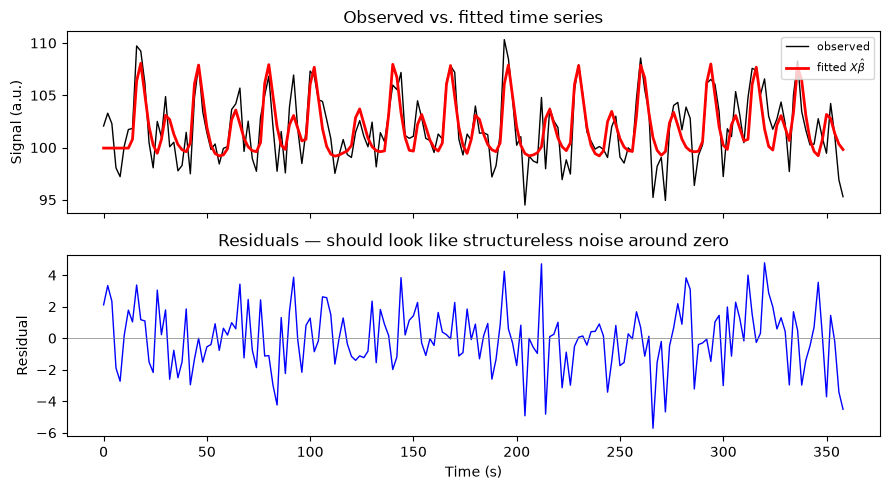

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

axes[0].plot(frame_times, y, "k-", lw=1, label="observed")
axes[0].plot(frame_times, fits, "r-", lw=2, label="fitted $X\\hat{\\beta}$")
axes[0].set(ylabel="Signal (a.u.)", title="Observed vs. fitted time series")
axes[0].legend(loc="upper right", fontsize=8)

axes[1].plot(frame_times, resid, "b-", lw=1)
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].set(xlabel="Time (s)", ylabel="Residual",
            title="Residuals — should look like structureless noise around zero")
plt.tight_layout()

Both task betas are highly significant, and $\hat{\sigma}^2$ is close to the true noise variance. The residuals look like featureless noise — exactly what we simulated. **With real fMRI data they would not**: residuals are autocorrelated across time, which makes OLS standard errors too small and t-values inflated. That is why real analyses use generalized least squares with prewhitening (Chapter 19).

## Step 4 — A simple contrast: A − B

Most scientific questions are comparisons: does condition A evoke a *larger* response than B? A **contrast** is a linear combination of parameters, $c^T\beta$. For A − B we use $c = [1, -1, 0]$, and its t-test uses the same variance machinery:

::::{div}
:class: eq-tip
$$
t = \frac{c^T\hat{\beta}}{\sqrt{\hat{\sigma}^2\, c^T (X^TX)^{-1} c}}
$$
:::{div}
:class: eq-tip-text
t — test statistic (df = n − p) · c — contrast weight vector · β̂ — estimated coefficients · σ̂² — estimated error variance · X — design matrix
:::
::::
:::{div}
:class: eq-where
*where* $c$ *is the vector of contrast weights,* $\hat{\beta}$ *the estimated coefficients,* $\hat{\sigma}^2$ *the estimated error variance, and* $X$ *the design matrix; the statistic follows a Student's t distribution with* $df_e = n - p$ *degrees of freedom.*
:::

The true contrast value in our simulation is $0.8 - 0.4 = 0.4$.

In [9]:
c = np.array([1.0, -1.0, 0.0])                 # contrast weights: +1 for A, -1 for B, 0 for intercept

contrast_val = c @ beta_hat
se_contrast = np.sqrt(sigma2_hat * c @ XtX_inv @ c)
t_contrast = contrast_val / se_contrast
p_contrast = 2 * stats.t.sf(abs(t_contrast), dfe)

print(f"Contrast A - B: value = {contrast_val:.3f} (true 0.4), "
      f"t({dfe}) = {t_contrast:.2f}, p = {p_contrast:.4g}")

Contrast A - B: value = 0.449 (true 0.4), t(177) = 8.23, p = 3.843e-14


A significant positive contrast means condition A evokes reliably more activity than condition B in this voxel. In a whole-brain analysis, this exact computation runs at every voxel, and the contrast values and t-statistics become maps. Chapter 20 develops contrast coding in depth.

## Where to go next

- **Chapter 19:** real fMRI noise is autocorrelated and drifts — GLS prewhitening and drift modeling make single-subject inference valid
- **Chapter 20:** contrasts and inference — how to code and test any comparison of conditions
- **Chapter 18.7:** when the canonical HRF does not fit, basis sets (HRF + derivatives, FIR) add flexibility, at the cost of the power–flexibility tradeoff

**Exercises**

1. Move the B onsets to occur 3 s after each A onset. What happens to the correlation between the two regressors, and to the standard errors and t-values? (This is design efficiency — Chapter 27.)
2. Add a slow linear drift to `y` without modeling it, and watch what happens to the estimates and $R^2$. Then add a drift column to `X` and refit.
3. Replace the IID noise with AR(1) noise (`e[t] = 0.5 * e[t-1] + w[t]`) and, over 1,000 simulations with `beta_true[:2] = 0`, count how often OLS declares a false positive at p < 0.05. You should see why prewhitening matters.